In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


In [3]:
df = pd.read_csv("adult.csv")


In [4]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [5]:
df.tail()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
48841,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


The Adult Income dataset contains demographic, education, employment, financial and working-hour information. The target variable is income, which contains two classes: <=50K and >50K.

In [6]:
df.dtypes

,0
age,int64
workclass,object
fnlwgt,int64
education,object
educational-num,int64
marital-status,object
occupation,object
relationship,object
race,object
gender,object


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


The dataset contains both: Numerical variables, such as age and hours worked per week. Categorical variables, such as workclass, occupation and marital status.

In [8]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


The statistical summary gives information about:

mean,
standard deviation,
minimum,
maximum,
quartiles,

for numerical variables.

In [9]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [10]:
question_marks = (df == "?").sum()


In [11]:
question_marks

,0
age,0
workclass,2799
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,2809
relationship,0
race,0
gender,0


In [12]:
df.duplicated().sum()

np.int64(52)

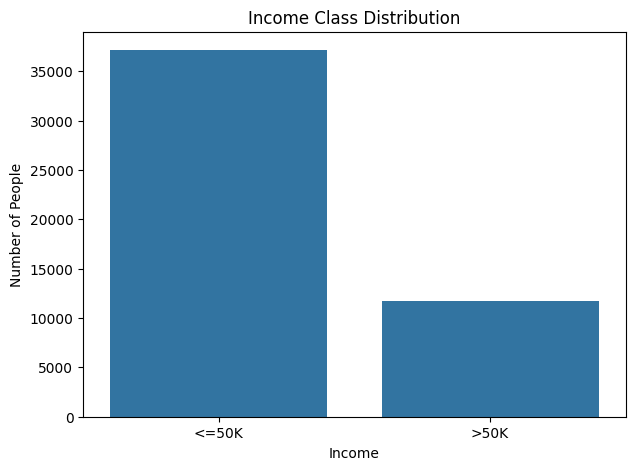

In [13]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="income")

plt.title("Income Class Distribution")
plt.xlabel("Income")
plt.ylabel("Number of People")

plt.show()

The graph shows the number of observations in each income category.

The two classes are not equally represented, so the classification model should not be evaluated using accuracy alone.

In [14]:
income_percentage = (
    df["income"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(income_percentage)

income
<=50K    76.07
>50K     23.93
Name: proportion, dtype: float64


This shows the percentage of individuals in each income class and helps determine whether the target variable is imbalanced.

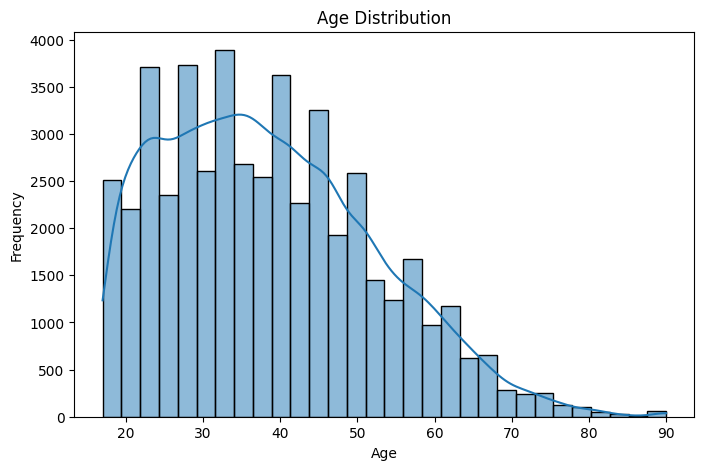

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

The histogram shows how ages are distributed in the dataset.

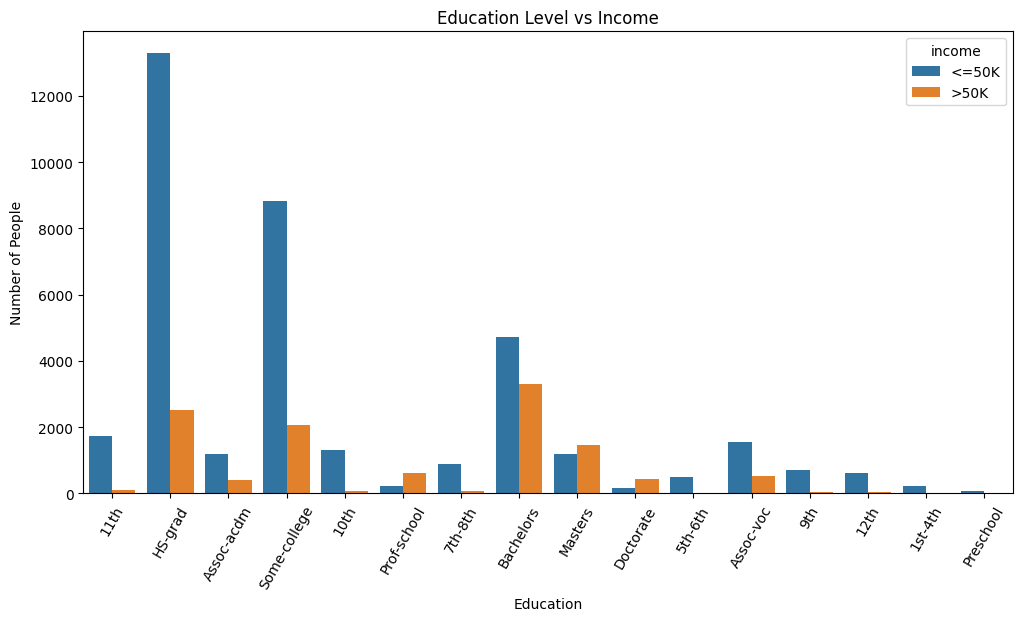

In [16]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="education",
    hue="income"
)

plt.xticks(rotation=60)

plt.title("Education Level vs Income")
plt.xlabel("Education")
plt.ylabel("Number of People")

plt.show()

The graph allows us to compare the distribution of income classes across education levels. It provides useful exploratory information for understanding the relationship between education-related attributes and the target.

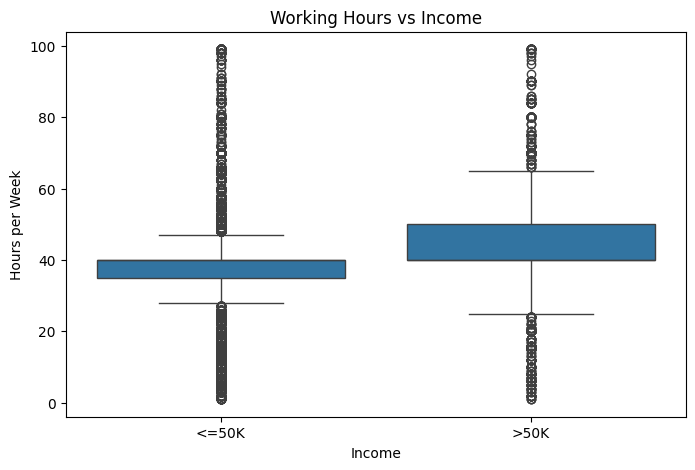

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="income",
    y="hours-per-week"
)

plt.title("Working Hours vs Income")
plt.xlabel("Income")
plt.ylabel("Hours per Week")

plt.show()

The boxplot compares the distribution of weekly working hours between the two income classes. It also helps identify unusually high or low working-hour observations.

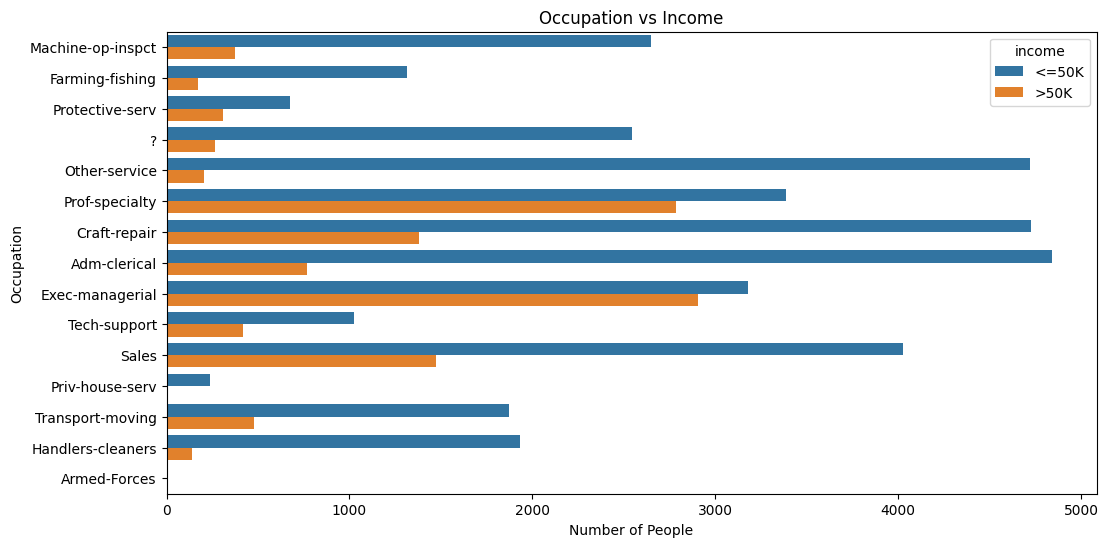

In [18]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    y="occupation",
    hue="income"
)

plt.title("Occupation vs Income")
plt.xlabel("Number of People")
plt.ylabel("Occupation")

plt.show()

Different occupations contain different proportions of the two income classes

In [19]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Current shape:", df.shape)

Current shape: (48842, 15)


In [20]:
for column in df.select_dtypes(include="object").columns:
    df[column] = df[column].str.strip()

print("Spaces removed from categorical values.")

Spaces removed from categorical values.


In [21]:
df = df.replace("?", np.nan)

print(df.isnull().sum())

age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64


In [22]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = df[column].fillna(
        df[column].mode()[0]
    )

print("Missing categorical values handled.")

Missing categorical values handled.


In [23]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


Missing categorical values were replaced with the most frequent category

In [24]:
before = len(df)

df = df.drop_duplicates()

after = len(df)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicates removed:", before - after)

Rows before removing duplicates: 48842
Rows after removing duplicates: 48789
Duplicates removed: 53


Duplicate observations were removed so that identical records do not unnecessarily influence model training.

In [25]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns

print("Numerical columns:")
print(list(numerical_columns))

Numerical columns:
['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']


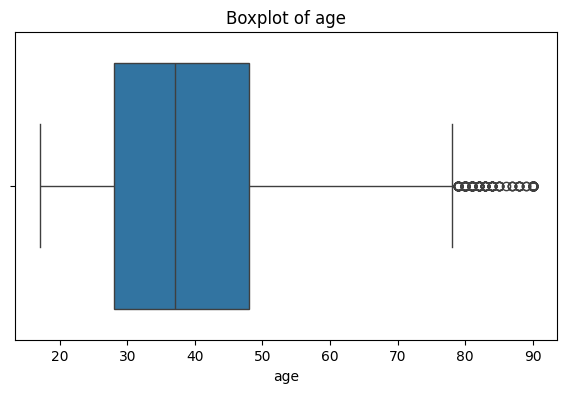

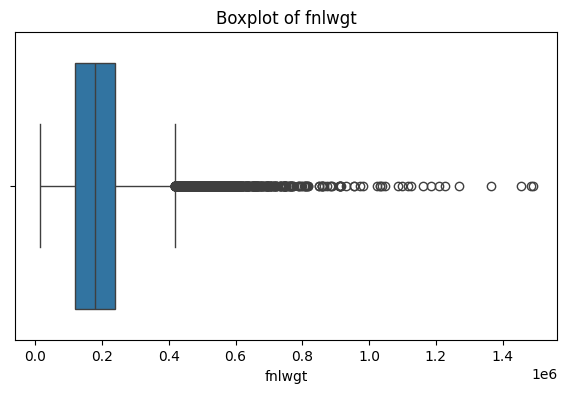

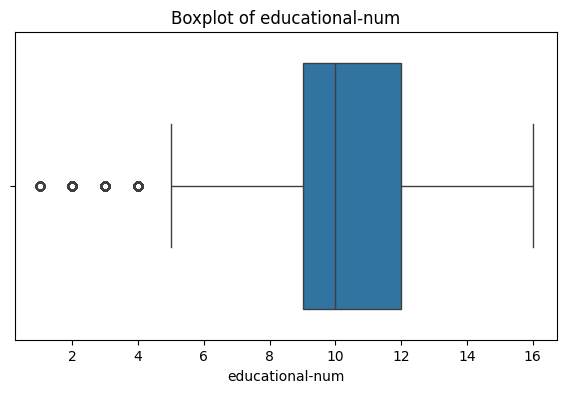

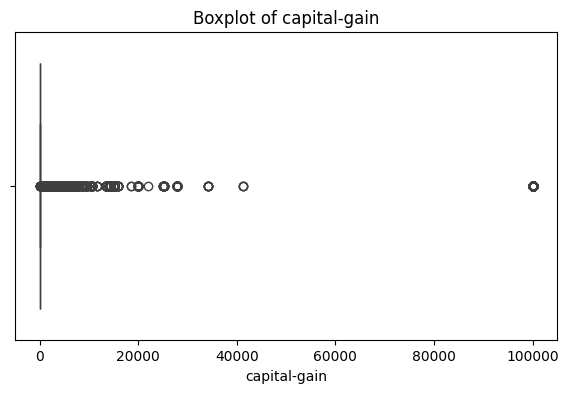

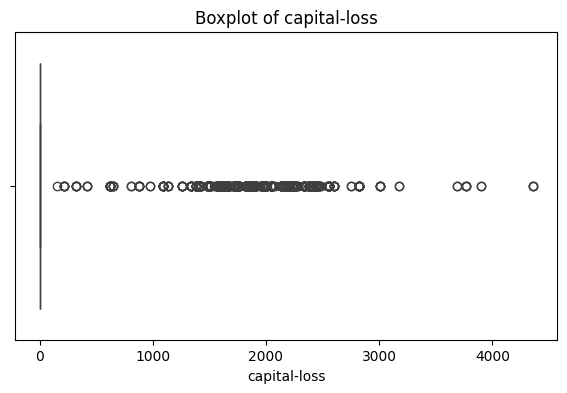

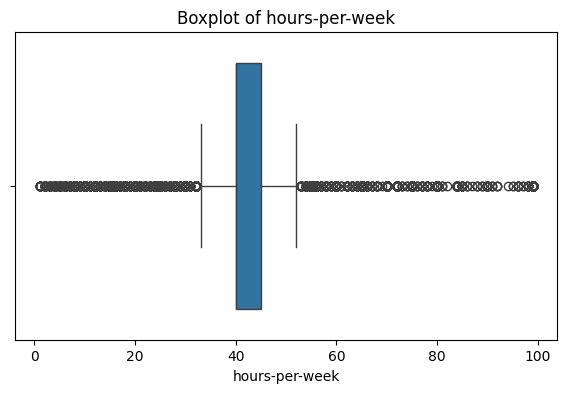

In [26]:
for column in numerical_columns:

    plt.figure(figsize=(7, 4))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)

    plt.show()

Some numerical variables may contain extreme observations. These values were inspected but not automatically removed because an extreme value can represent a valid person rather than a data-entry error.

In [27]:
df["total-capital"] = (
    df["capital-gain"] -
    df["capital-loss"]
)

df[[
    "capital-gain",
    "capital-loss",
    "total-capital"
]].head()

,capital-gain,capital-loss,total-capital
0,0,0,0
1,0,0,0
2,0,0,0
3,7688,0,7688
4,0,0,0


total-capital combines capital gains and losses into one additional numerical feature.

In [28]:
df["age-group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 50, 65, 100],
    labels=[
        "Young",
        "Early_Adult",
        "Middle_Age",
        "Senior",
        "Older"
    ]
)

print(df["age-group"].value_counts())

age-group
Middle_Age     16674
Early_Adult    12710
Young           9598
Senior          8005
Older           1802
Name: count, dtype: int64


The age-group feature provides a categorical representation of broad age ranges while retaining the original numerical age feature.

In [29]:
df = df.drop(columns=["education"])

print(df.columns.tolist())

['age', 'workclass', 'fnlwgt', 'educational-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income', 'total-capital', 'age-group']


The categorical education feature was removed while retaining educational-num. This reduces redundancy while preserving education-related information.

In [30]:
print("Final dataset shape:", df.shape)

print("\nFinal columns:")
print(df.columns.tolist())

Final dataset shape: (48789, 16)

Final columns:
['age', 'workclass', 'fnlwgt', 'educational-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income', 'total-capital', 'age-group']


In [31]:
X = df.drop(columns=["income"])
y = df["income"]

In [32]:
y = y.map({
    "<=50K": 0,
    ">50K": 1
})

print(y.value_counts())

income
0    37108
1    11681
Name: count, dtype: int64


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 39031
Testing samples: 9758


80% of the data is used for training and 20% for testing.

stratify=y maintains a similar target-class distribution in both sets.

In [34]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'total-capital']

Categorical features:
['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'age-group']


In [35]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [36]:
numerical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [37]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_transformer,
            numerical_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


This satisfies the vectorization and scaling requirements.

In [39]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [40]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=10,
                random_state=42
            )
        )
    ]
)

decision_tree_model.fit(
    X_train,
    y_train
)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [41]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

results = []

for name, model in models.items():

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions
        ),
        "Recall": recall_score(
            y_test,
            predictions
        ),
        "F1 Score": f1_score(
            y_test,
            predictions
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            probabilities
        )
    })

results_df = pd.DataFrame(results)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8521,0.7327,0.6019,0.6609,0.9061
1,Decision Tree,0.8524,0.7416,0.5886,0.6563,0.8946
2,Random Forest,0.8520,0.7176,0.6297,0.6708,0.9007


Three classification models were trained and compared using accuracy, precision, recall, F1-score and ROC-AUC. Since the target classes are not perfectly balanced, F1-score and ROC-AUC were also considered rather than relying only on accuracy.

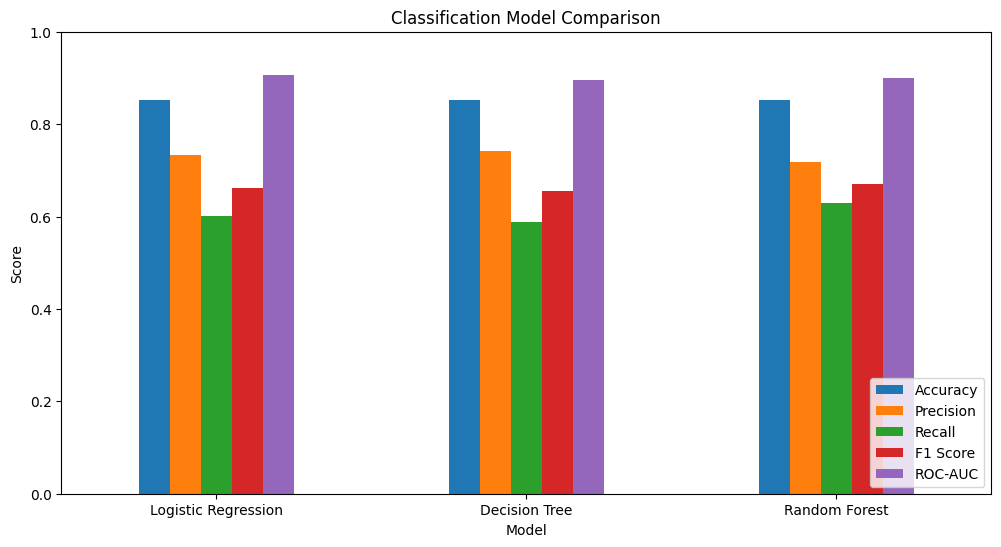

In [43]:
results_plot = results_df.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Classification Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

The graph provides a visual comparison of the three classifiers across multiple evaluation metrics.

In [44]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    )

    print("\n", name)
    print("Fold scores:", np.round(scores, 4))
    print("Mean F1:", round(scores.mean(), 4))
    print("Standard deviation:", round(scores.std(), 4))


 Logistic Regression
Fold scores: [0.6544 0.6663 0.6588 0.6827 0.6734]
Mean F1: 0.6671
Standard deviation: 0.0101

 Decision Tree
Fold scores: [0.663  0.6681 0.6532 0.6709 0.672 ]
Mean F1: 0.6654
Standard deviation: 0.0069

 Random Forest
Fold scores: [0.6649 0.6717 0.6721 0.6784 0.6741]
Mean F1: 0.6722
Standard deviation: 0.0044


The mean F1-score indicates average performance, while the standard deviation indicates how much the score changes between folds.

In [45]:
final_model = random_forest_model

print("Final model selected: Random Forest")

Final model selected: Random Forest


In [46]:
from sklearn.metrics import classification_report

final_predictions = final_model.predict(X_test)

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=[
            "<=50K",
            ">50K"
        ]
    )
)

              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.90      7422
        >50K       0.72      0.63      0.67      2336

    accuracy                           0.85      9758
   macro avg       0.80      0.78      0.79      9758
weighted avg       0.85      0.85      0.85      9758



The classification report provides class-specific:

precision,
recall,
F1-score,
support.

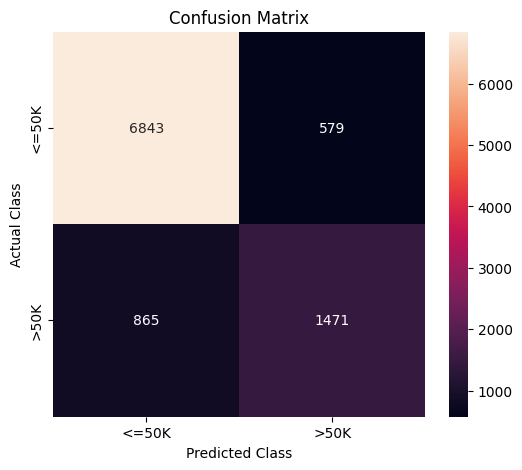

In [47]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    final_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "<=50K",
        ">50K"
    ],
    yticklabels=[
        "<=50K",
        ">50K"
    ]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

plt.show()

The confusion matrix shows four types of outcomes:

Correct <=50K,
Incorrectly predicted >50K for an actual <=50K,
Incorrectly predicted <=50K for an actual >50K,
Correct >50K.

This helps identify which income class is more difficult for the model to classify.

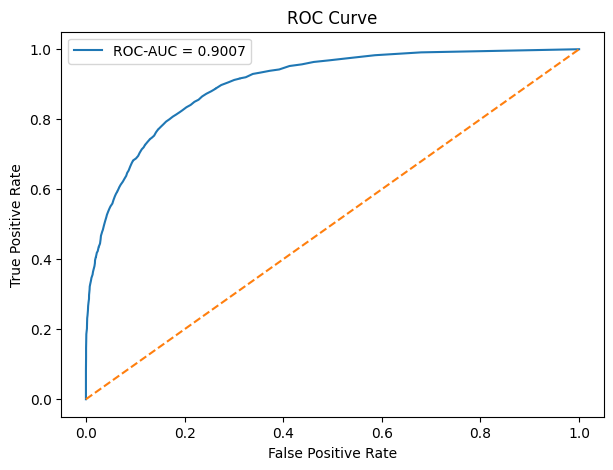

In [48]:
from sklearn.metrics import roc_curve, auc

final_probabilities = final_model.predict_proba(
    X_test
)[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    final_probabilities
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

The ROC curve evaluates how well the model separates the two income classes at different probability thresholds.

In [49]:
classifier = final_model.named_steps["classifier"]

if hasattr(classifier, "feature_importances_"):

    feature_names = (
        final_model
        .named_steps["preprocessor"]
        .get_feature_names_out()
    )

    importance_values = (
        classifier.feature_importances_
    )

    feature_importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance_values
    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    feature_importance.head(20)

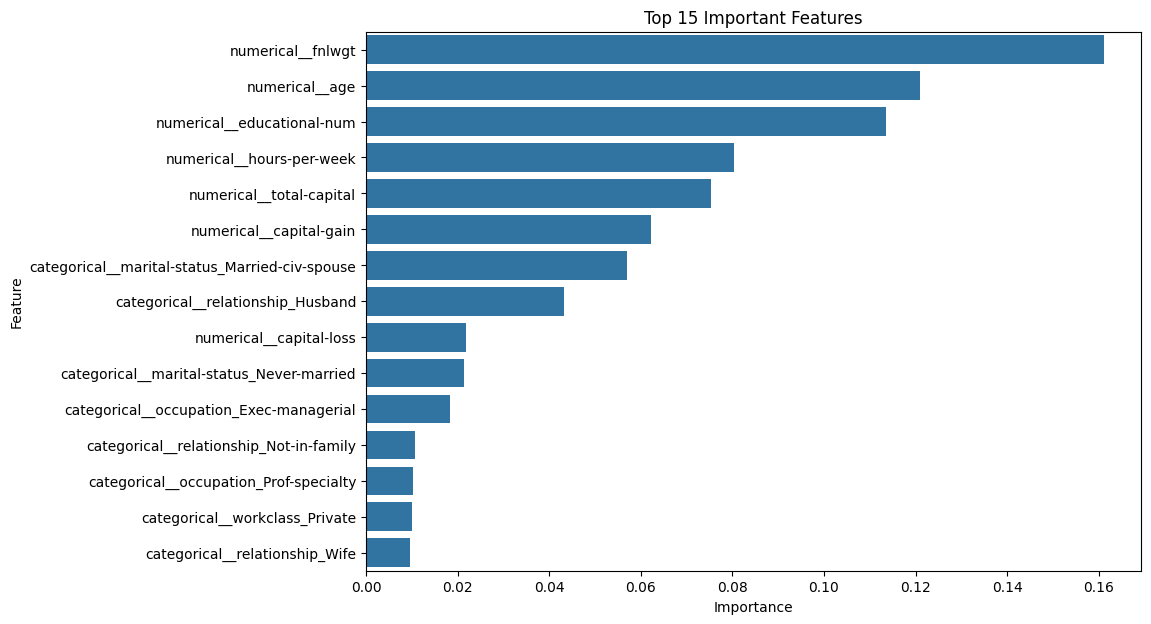

In [50]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

The feature-importance analysis identifies the variables that contributed most to the final tree-based classifier's predictions.

In [51]:
import joblib

joblib.dump(
    final_model,
    "adult_income_classifier.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [52]:
import os

print(
    "File exists:",
    os.path.exists("adult_income_classifier.pkl")
)

print(
    "File size:",
    os.path.getsize("adult_income_classifier.pkl"),
    "bytes"
)

File exists: True
File size: 107093755 bytes


In [53]:
loaded_model = joblib.load(
    "adult_income_classifier.pkl"
)

print("Saved model loaded successfully!")

Saved model loaded successfully!


In [54]:
sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)[0]

probability = loaded_model.predict_proba(
    sample
)[0]

print("Prediction:", prediction)
print("Probability for <=50K:", round(probability[0], 4))
print("Probability for >50K:", round(probability[1], 4))

Prediction: 1
Probability for <=50K: 0.02
Probability for >50K: 0.98


In [55]:
if prediction == 1:
    print("Predicted Income: >50K")
else:
    print("Predicted Income: <=50K")

Predicted Income: >50K
